# Lab 1: Getting Started with Data and AI — SOLUTION
## MPS311/439 — Machine Learning

This notebook contains working code and indicative answers. Student observations may use different wording when they match the output.

## Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

DATA_URL = "https://raw.githubusercontent.com/wayXing/mps311-439-course-materials/main/lecture-slids/lessons/lesson1/lab/bike_rentals.csv"
df = pd.read_csv(DATA_URL)

print("Dataset loaded successfully.")
print("Rows and columns:", df.shape)

Matplotlib is building the font cache; this may take a moment.


Dataset loaded successfully.
Rows and columns: (337, 9)


In [2]:
message = "My Lesson 1 notebook is working."
print(message)

My Lesson 1 notebook is working.


## Part 1: Meet the dataset

In [3]:
df.head()

,date,day,hour,temperature_c,humidity_pct,wind_speed_kmh,weather,is_weekend,rentals
0,2025-09-15,Monday,0,10.2,76.0,4.6,Clear,0,24
1,2025-09-15,Monday,1,8.3,75.0,6.2,Clear,0,4
2,2025-09-15,Monday,2,11.0,71.0,4.6,Clear,0,25
3,2025-09-15,Monday,3,11.8,70.0,5.6,Clear,0,25
4,2025-09-15,Monday,4,11.8,77.0,7.0,Clear,0,10


One row represents the weather conditions and number of bicycle rentals during one hour.

In [4]:
print("Rows and columns:", df.shape)
print("Column names:", df.columns.tolist())

Rows and columns: (337, 9)
Column names: ['date', 'day', 'hour', 'temperature_c', 'humidity_pct', 'wind_speed_kmh', 'weather', 'is_weekend', 'rentals']


## Part 2: Inspect the data

In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 337 entries, 0 to 336
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            337 non-null    str    
 1   day             337 non-null    str    
 2   hour            337 non-null    int64  
 3   temperature_c   336 non-null    float64
 4   humidity_pct    336 non-null    float64
 5   wind_speed_kmh  336 non-null    float64
 6   weather         337 non-null    str    
 7   is_weekend      337 non-null    int64  
 8   rentals         337 non-null    int64  
dtypes: float64(3), int64(3), str(3)
memory usage: 23.8 KB


,hour,temperature_c,humidity_pct,wind_speed_kmh,is_weekend,rentals
count,337.000000,336.000000,336.000000,336.000000,337.000000,337.000000
mean,11.465875,14.010417,71.571429,8.111905,0.287834,60.525223
std,6.950475,4.537826,7.751800,2.066082,0.453427,47.577194
min,0.000000,4.000000,56.000000,4.500000,0.000000,4.000000
25%,5.000000,10.075000,66.000000,6.475000,0.000000,10.000000
50%,11.000000,13.900000,71.000000,8.150000,0.000000,58.000000
75%,17.000000,18.025000,76.000000,9.800000,1.000000,97.000000
max,23.000000,23.300000,94.000000,12.700000,1.000000,162.000000


The non-null counts show missing entries in `temperature_c`, `humidity_pct`, and `wind_speed_kmh`. The exact minimum, mean, and maximum for `rentals` appear in the summary above; the maximum should be larger than the mean and minimum.

## Part 3: Check data quality and use AI

In [6]:
missing_values = df.isna().sum()
print(missing_values)

duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

date              0
day               0
hour              0
temperature_c     1
humidity_pct      1
wind_speed_kmh    1
weather           0
is_weekend        0
rentals           0
dtype: int64
Duplicate rows: 1


In [7]:
df_clean = df.drop_duplicates().dropna().copy()

print("Original shape:", df.shape)
print("Clean shape:   ", df_clean.shape)

Original shape: (337, 9)
Clean shape:    (333, 9)


The worksheet intentionally uses `weather_type`, which does not exist. The smallest correction is to use the actual column name `weather`. Successful output should list counts for Clear, Cloudy, and Rain.

In [8]:
df_clean["weather"].value_counts()

weather
Clear     180
Cloudy    113
Rain       40
Name: count, dtype: int64

## Part 4: Make three simple plots

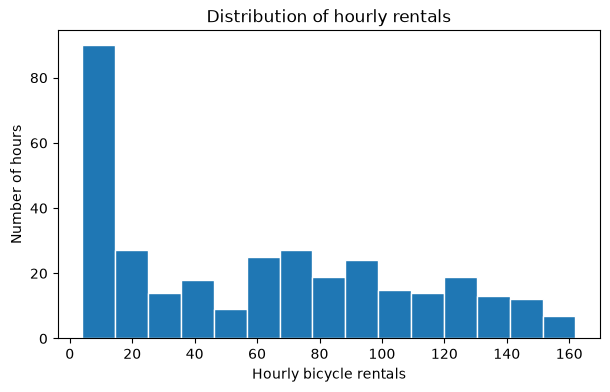

In [9]:
plt.figure(figsize=(7, 4))
plt.hist(df_clean["rentals"], bins=15, edgecolor="white")
plt.xlabel("Hourly bicycle rentals")
plt.ylabel("Number of hours")
plt.title("Distribution of hourly rentals")
plt.show()

Most hours lie toward the lower-to-middle part of the rental range, while a smaller number of hours have very high demand.

weather
Clear     72.138889
Cloudy    55.654867
Rain      22.725000
Name: rentals, dtype: float64


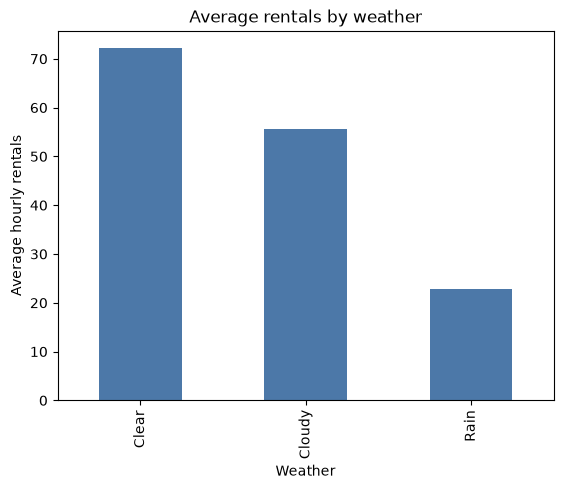

In [10]:
rentals_by_weather = df_clean.groupby("weather")["rentals"].mean()
print(rentals_by_weather)

rentals_by_weather.plot(kind="bar", color="#4C78A8")
plt.xlabel("Weather")
plt.ylabel("Average hourly rentals")
plt.title("Average rentals by weather")
plt.show()

Clear weather has the highest average rentals in this dataset.

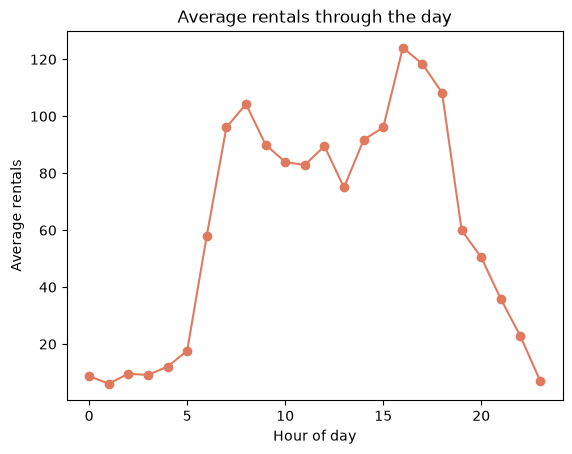

In [11]:
rentals_by_hour = df_clean.groupby("hour")["rentals"].mean()

rentals_by_hour.plot(kind="line", marker="o", color="#E07A5F")
plt.xlabel("Hour of day")
plt.ylabel("Average rentals")
plt.title("Average rentals through the day")
plt.show()

The hourly plot has morning and late-afternoon peaks. A suitable final reflection is: the data show that bicycle rentals vary strongly across the day. AI helped diagnose a column-name error by comparing the requested name with the actual columns.

# MPS439 extension — sample solutions

## Option A: Compare weekdays and weekends

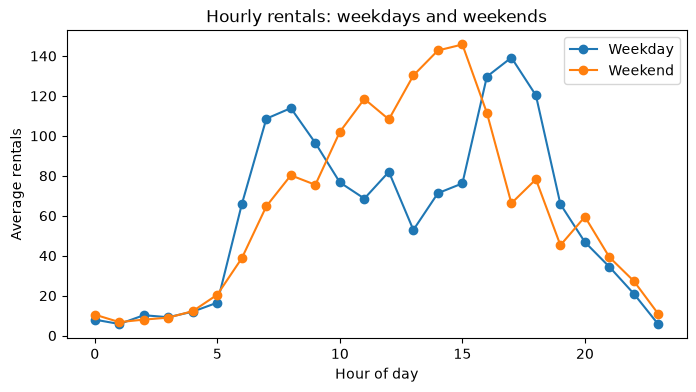

In [12]:
hourly_by_group = (
    df_clean.groupby(["hour", "is_weekend"])["rentals"]
            .mean()
            .unstack()
)

hourly_by_group.plot(marker="o", figsize=(8, 4))
plt.xlabel("Hour of day")
plt.ylabel("Average rentals")
plt.title("Hourly rentals: weekdays and weekends")
plt.legend(["Weekday", "Weekend"])
plt.show()

Both groups have low overnight demand, but weekday demand has sharper commuting peaks while weekend demand is spread more broadly through the day. An overall average can hide these different shapes.

## Option B: Reusable plotting function

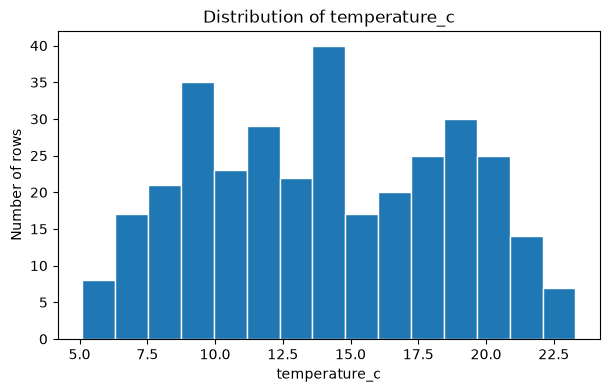

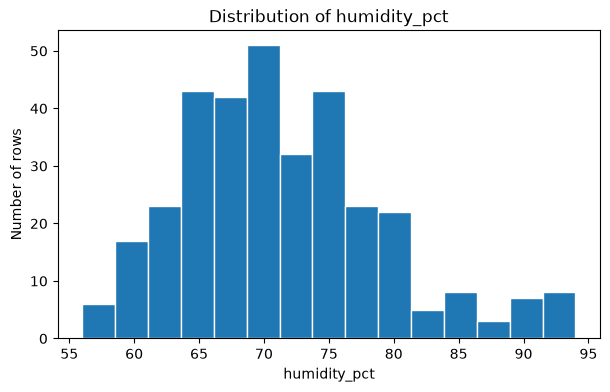

In [13]:
def plot_distribution(data, column):
    plt.figure(figsize=(7, 4))
    plt.hist(data[column], bins=15, edgecolor="white")
    plt.xlabel(column)
    plt.ylabel("Number of rows")
    plt.title(f"Distribution of {column}")
    plt.show()

plot_distribution(df_clean, "temperature_c")
plot_distribution(df_clean, "humidity_pct")

A function keeps the plotting steps in one place and lets us apply the same analysis consistently to several columns.

## Options C and D

Answers depend on the chosen question. A strong response checks every AI-generated column name and operation, modifies at least one weak choice, and keeps the conclusion within what the displayed evidence supports.